#### Supp. Fig 4d, Supp. Fig 7b

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import torch 
import os

pd.set_option('display.max_columns',500)
pd.set_option('display.max_categories',60)
pd.set_option('display.max_rows', 500)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'axes.facecolor': 'white',
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})

In [2]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/nfact12/h5ad/adata_vis_assigned_cell_types_nfact12_assigned_factors_log_minmax.h5ad")


In [3]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,ATI/Endo,Perib. FB,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC,ATII,Plasma,ATI/Endo_log_minmax,Perib. FB_log_minmax,Airway_log_minmax,B_log_minmax,Alv. macro_log_minmax,Alv. FB/immune_log_minmax,Adv. FB_log_minmax,Macro_log_minmax,Immune_log_minmax,SMC_log_minmax,ATII_log_minmax,Plasma_log_minmax,factor_assigned
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,0.773084,0.000000,0.717544,0.502845,0.000000,0.620036,0.000000,0.000000,0.740151,B
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266

In [4]:
niches = np.unique(adata_vis.obs['factor_assigned'])

In [5]:
df = adata_vis[(adata_vis.obs['cond']!="UNC") &     (adata_vis.obs['factor_assigned'].isin(niches))].obs[['library_id','cond','lobe_lr','sex', 'probe_lot', "lobe",'outcome_long','outcome_24m', 'factor_assigned']]

In [24]:
df

,library_id,cond,lobe_lr,sex,probe_lot,lobe,outcome_long,outcome_24m,factor_assigned
AACACGTGCATCGCAC-1-18_57617_A1,18_57617_A1,IPF,left,M,203531,upper,DEAD,DEAD,B
AACACTTGGCAAGGAA-1-18_57617_A1,18_57617_A1,IPF,left,M,203531,upper,DEAD,DEAD,ATI/Endo
AACAGGATTCATAGTT-1-18_57617_A1,18_57617_A1,IPF,left,M,203531,upper,DEAD,DEAD,ATI/Endo
AACAGGTTCACCGAAG-1-18_57617_A1,18_57617_A1,IPF,left,M,203531,upper,DEAD,DEAD,ATI/Endo
AACAGTCAGGCTCCGC-1-18_57617_A1,18_57617_A1,IPF,left,M,203531,upper,DEAD,DEAD,Macro
...,...,...,...,...,...,...,...,...,...
TGTTCATTGGTCCAAG-1-22_16220_B1,22_16220_B1,IPF,right,F,203947,middle,ALIVE,ALIVE,ATI/Endo
TGTTGCGTCCAAGATT-1-22_16220_B1,22_16220_B1,IPF,right,F,203947,middle,ALIVE,ALIVE,ATI/Endo
TGTTGGAAGCTCGGTA-1-22_16220_B1,22_16220_B1,IPF,right,F,203947,middle,ALIVE,ALIVE,ATI/Endo
TGTTGGATGGACTTCT-1-22_16220_B1,22_16220_B1,IPF,right,F,203947,middle,ALIVE,ALIVE,ATII


In [6]:
# Create a blank dataframe
counts = df.groupby(['library_id', 'factor_assigned']).size().reset_index(name='count')


/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_70220/525618459.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['library_id', 'factor_assigned']).size().reset_index(name='count')


In [7]:
# Step 2: Compute proportions per library_id
total_counts = counts.groupby(['library_id'])['count'].transform('sum')
counts['proportion'] = counts['count'] / total_counts

# Step 3: Pivot to get factor_assigned proportions per library_id
pivot_df = counts.pivot_table(
    index='library_id',
    columns='factor_assigned',
    values='proportion',
    fill_value=0
)
# Re-order columns
pivot_df = pivot_df[['ATI/Endo', 'Alv. FB/immune', 'Plasma', 'SMC', 'ATII',
                  'Immune', 'Airway', 'Adv. FB', 'Perib. FB', 'Alv. macro',
                  'Macro', 'B']]

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_70220/4124322398.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_counts = counts.groupby(['library_id'])['count'].transform('sum')
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_70220/4124322398.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = counts.pivot_table(


In [8]:
cond_order = df[['library_id', 'cond']].drop_duplicates().set_index('library_id').sort_index()
cond_order

,cond
library_id,
06_30914_A1,NSIP
08_38774_B2,CHP
11_13888_A1,CHP
16_39724_B1,CHP
17_25789_B1,CHP
18_57617_A1,IPF
19_18542_A4,NSIP
19_35057_C3,NSIP
20_17688_B2,NSIP


In [9]:
lobe_order = df[['library_id', 'lobe']].drop_duplicates().set_index('library_id').sort_index()
lobe_order


,lobe
library_id,
06_30914_A1,lower
08_38774_B2,upper
11_13888_A1,lower
16_39724_B1,lower
17_25789_B1,upper
18_57617_A1,upper
19_18542_A4,middle
19_35057_C3,lower
20_17688_B2,upper


In [10]:
lobe_lr_order = df[['library_id', 'lobe_lr']].drop_duplicates().set_index('library_id').sort_index()
lobe_order = df[['library_id', 'lobe']].drop_duplicates().set_index('library_id').sort_index()
outcome_24m_order = df[['library_id', 'outcome_24m']].drop_duplicates().set_index('library_id').sort_index()
outcome_long_order = df[['library_id', 'outcome_long']].drop_duplicates().set_index('library_id').sort_index()
sex_order = df[['library_id', 'sex']].drop_duplicates().set_index('library_id').sort_index()
probe_order  = df[['library_id', 'probe_lot']].drop_duplicates().set_index('library_id').sort_index()

In [11]:
probe_order

,probe_lot
library_id,
06_30914_A1,203947
08_38774_B2,203947
11_13888_A1,203947
16_39724_B1,203947
17_25789_B1,203947
18_57617_A1,203531
19_18542_A4,203947
19_35057_C3,203531
20_17688_B2,203531


In [12]:
pivot_df['cond'] = cond_order['cond']
pivot_df['lobe'] = lobe_order['lobe']
pivot_df['lobe_lr'] = lobe_lr_order['lobe_lr']
pivot_df['outcome_24m'] = outcome_24m_order['outcome_24m']
pivot_df['outcome_long'] = outcome_long_order['outcome_long']
pivot_df['sex'] = sex_order['sex']
#pivot_df['probe'] = probe_order['probe_lot']



In [32]:
#pivot_df['probe'] = pivot_df['probe_order'].astype(str)

In [13]:
pivot_df['cond']  = pd.Categorical(pivot_df['cond'], categories=["IPF","NSIP",'CHP'], ordered=True)


In [14]:
pivot_df.sort_values("cond")

factor_assigned,ATI/Endo,Alv. FB/immune,Plasma,SMC,ATII,Immune,Airway,Adv. FB,Perib. FB,Alv. macro,Macro,B,cond,lobe,lobe_lr,outcome_24m,outcome_long,sex
library_id,,,,,,,,,,,,,,,,,,
22_16220_B1,0.542927,0.122350,0.010080,0.014946,0.120264,0.023983,0.012513,0.046576,0.038234,0.037887,0.029892,0.000348,IPF,middle,right,ALIVE,ALIVE,F
21_55747_C3,0.239445,0.277883,0.009137,0.073409,0.142407,0.012287,0.040013,0.171708,0.012287,0.020794,0.000630,0.000000,IPF,lower,right,ALIVE,ALIVE,M
21_24095_A3,0.410357,0.384361,0.001238,0.038168,0.020425,0.038993,0.023932,0.023107,0.043326,0.011554,0.003507,0.001032,IPF,NaN,right,ALIVE,ALIVE,M
18_57617_A1,0.422113,0.201843,0.021883,0.046070,0.012669,0.032249,0.026202,0.018140,0.143968,0.021307,0.040311,0.013245,IPF,upper,left,DEAD,DEAD,M
21_06301_B2,0.245984,0.320315,0.125039,0.032756,0.036220,0.081575,0.108346,0.011654,0.019843,0.012598,0.005039,0.000630,IPF,middle,right,ALIVE,ALIVE,M
20_41615_B1,0.224578,0.262339,0.031467,0.097383,0.057304,0.020868,0.053660,0.196091,0.047698,0.002981,0.005631,0.000000,IPF,upper,left,ALIVE,LTx,M
20_41501_C1,0.408750,0.278540,0.010872,0.075848,0.088791,0.031841,0.074553,0.002071,0.006989,0.011908,0.008801,0.001035,IPF,upper,right,DEAD,DEAD,M
20_33940_B2,0.364588,0.227617,0.138530,0.083964,0.051002,0.019376,0.061024,0.009131,0.008463,0.030958,0.003563,0.001782,IPF,lower,right,ALIVE,DEAD,M
20_24241_A2,0.337209,0.277585,0.000990,0.067788,0.029688,0.022266,0.131618,0.052202,0.066551,0.002721,0.011381,0.000000,IPF,middle,right,ALIVE,ALIVE,M


In [15]:
pivot_df.sort_values("lobe")

factor_assigned,ATI/Endo,Alv. FB/immune,Plasma,SMC,ATII,Immune,Airway,Adv. FB,Perib. FB,Alv. macro,Macro,B,cond,lobe,lobe_lr,outcome_24m,outcome_long,sex
library_id,,,,,,,,,,,,,,,,,,
06_30914_A1,0.638118,0.031063,0.017085,0.021522,0.005769,0.182161,0.002884,0.029732,0.000000,0.004438,0.063013,0.004216,NSIP,lower,right,ALIVE,ALIVE,F
21_55747_C3,0.239445,0.277883,0.009137,0.073409,0.142407,0.012287,0.040013,0.171708,0.012287,0.020794,0.000630,0.000000,IPF,lower,right,ALIVE,ALIVE,M
20_33940_B2,0.364588,0.227617,0.138530,0.083964,0.051002,0.019376,0.061024,0.009131,0.008463,0.030958,0.003563,0.001782,IPF,lower,right,ALIVE,DEAD,M
19_35057_C3,0.812804,0.042450,0.001160,0.026444,0.023892,0.005103,0.028764,0.032243,0.005799,0.021341,0.000000,0.000000,NSIP,lower,right,ALIVE,ALIVE,M
20_33362_C4,0.058580,0.082776,0.525310,0.065903,0.078956,0.104744,0.025470,0.012735,0.037886,0.001910,0.005094,0.000637,NSIP,lower,right,ALIVE,ALIVE,M
16_39724_B1,0.526996,0.087452,0.000380,0.021293,0.195437,0.011787,0.012548,0.094677,0.005323,0.003422,0.040684,0.000000,CHP,lower,right,ALIVE,ALIVE,M
11_13888_A1,0.875311,0.021012,0.000829,0.013824,0.000829,0.001659,0.008294,0.074924,0.000000,0.002212,0.001106,0.000000,CHP,lower,left,ALIVE,ALIVE,M
19_18542_A4,0.202880,0.313191,0.000000,0.181023,0.020057,0.000000,0.020057,0.004371,0.246079,0.006943,0.005400,0.000000,NSIP,middle,right,DEAD,DEAD,M
20_22642_A1,0.029387,0.300085,0.201469,0.064708,0.018932,0.033060,0.088443,0.232269,0.000565,0.003673,0.007912,0.019497,NSIP,middle,left,ALIVE,ALIVE,M


In [16]:
save_dir = "figs"
os.makedirs(save_dir, exist_ok=True)

In [17]:
pivot_df

factor_assigned,ATI/Endo,Alv. FB/immune,Plasma,SMC,ATII,Immune,Airway,Adv. FB,Perib. FB,Alv. macro,Macro,B,cond,lobe,lobe_lr,outcome_24m,outcome_long,sex
library_id,,,,,,,,,,,,,,,,,,
06_30914_A1,0.638118,0.031063,0.017085,0.021522,0.005769,0.182161,0.002884,0.029732,0.000000,0.004438,0.063013,0.004216,NSIP,lower,right,ALIVE,ALIVE,F
08_38774_B2,0.292816,0.537864,0.001553,0.078058,0.012816,0.025243,0.023689,0.013592,0.002330,0.010485,0.000388,0.001165,CHP,upper,right,ALIVE,ALIVE,F
11_13888_A1,0.875311,0.021012,0.000829,0.013824,0.000829,0.001659,0.008294,0.074924,0.000000,0.002212,0.001106,0.000000,CHP,lower,left,ALIVE,ALIVE,M
16_39724_B1,0.526996,0.087452,0.000380,0.021293,0.195437,0.011787,0.012548,0.094677,0.005323,0.003422,0.040684,0.000000,CHP,lower,right,ALIVE,ALIVE,M
17_25789_B1,0.743604,0.136364,0.006805,0.031301,0.008165,0.012793,0.003811,0.004627,0.004083,0.037561,0.010615,0.000272,CHP,upper,right,ALIVE,DEAD,F
18_57617_A1,0.422113,0.201843,0.021883,0.046070,0.012669,0.032249,0.026202,0.018140,0.143968,0.021307,0.040311,0.013245,IPF,upper,left,DEAD,DEAD,M
19_18542_A4,0.202880,0.313191,0.000000,0.181023,0.020057,0.000000,0.020057,0.004371,0.246079,0.006943,0.005400,0.000000,NSIP,middle,right,DEAD,DEAD,M
19_35057_C3,0.812804,0.042450,0.001160,0.026444,0.023892,0.005103,0.028764,0.032243,0.005799,0.021341,0.000000,0.000000,NSIP,lower,right,ALIVE,ALIVE,M
20_17688_B2,0.352537,0.324448,0.034394,0.068501,0.025795,0.005732,0.157352,0.008312,0.001146,0.003726,0.009745,0.008312,NSIP,upper,right,ALIVE,LTx,F


In [18]:
# Create new column "lay_id" from "cond_rep", replacing _ with # to look better
adata_vis.obs['lay_id'] = adata_vis.obs['cond_rep'].astype(str).str.replace("_"," #")

In [19]:
# So that we can dynamically switch library_id (key) with lay_id (value)
key_map = dict(zip(adata_vis.obs['library_id'].drop_duplicates(), adata_vis.obs['lay_id'].drop_duplicates()))
key_map

{'18_57617_A1': 'IPF #1',
 '20_33940_B2': 'IPF #2',
 '20_24241_A2': 'IPF #3',
 '19_35057_C3': 'NSIP #1',
 '20_17688_B2': 'NSIP #2',
 '20_28197_A1': 'IPF #4',
 '20_22642_A1': 'NSIP #3',
 '20_41501_C1': 'IPF #5',
 '20_33362_C4': 'NSIP #4',
 '20_41847_A1': 'UNC #1',
 '20_41615_B1': 'IPF #6',
 '21_06301_B2': 'IPF #7',
 '21_05738_A1': 'UNC #2',
 '21_57231_A3': 'CHP #1',
 '21_25528_A3': 'UNC #3',
 '22_18446_A1': 'UNC #4',
 '22_18440_A2': 'CHP #2',
 '23_15209_A3': 'CHP #3',
 '22_50637_A1': 'UNC #5',
 '23_50343_B2': 'CHP #4',
 '23_41922_B2': 'CHP #5',
 '24_10794_B1': 'UNC #7',
 '20_12743_C1': 'UNC #8',
 '21_55244_B1': 'UNC #9',
 '23_45450_A3': 'UNC #10',
 '24_23755_A1': 'UNC #11',
 '16_53837_A10': 'UNC #12',
 '19_48719_A1': 'UNC #13',
 '17_35291_B1': 'UNC #14',
 '16_46257_A1': 'UNC #15',
 '18_23779_A2': 'UNC #16',
 '12_39986_A2': 'UNC #17',
 '20_26330_B3': 'NSIP #5',
 '21_24837_A1': 'NSIP #6',
 '06_30914_A1': 'NSIP #7',
 '19_18542_A4': 'NSIP #8',
 '24_27523_C5': 'CHP #6',
 '11_13888_A1': 'CHP 

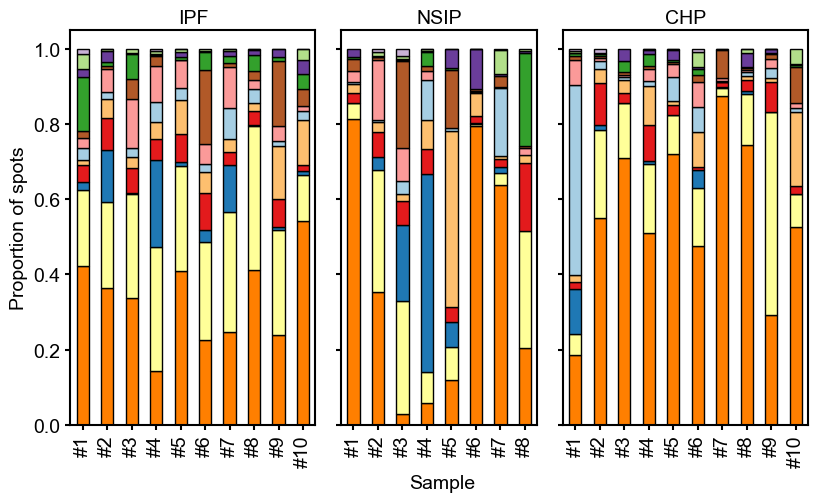

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_70220/4015162553.py:84: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_legend.show()


<Figure size 400x200 with 0 Axes>

In [33]:
conditions = ["IPF","NSIP","CHP"]

import matplotlib.gridspec as gridspec

# Custom width ratios (adjust as needed — one per condition)
widths = [
    pivot_df[pivot_df['cond'] == conditions[0]].shape[0] * 0.15,
    pivot_df[pivot_df['cond'] == conditions[1]].shape[0] * 0.15,
    pivot_df[pivot_df['cond'] == conditions[2]].shape[0] * 0.15
]

fig = plt.figure(figsize=(sum(widths) * 2, 5))  # overall figure size
gs = gridspec.GridSpec(1, len(conditions), width_ratios=widths)

axes = [fig.add_subplot(gs[i]) for i in range(len(conditions))]



# Step 3: Set up subplots
#fig, axes = plt.subplots(1, len(conditions), figsize=(3 * len(conditions), 5), sharey=True)

# Custom color palette
color_dict = dict(zip(
['ATI/Endo',
 'Perib. FB',
 'ATII',
 'Plasma',
 'Airway',
 'B',
 'Alv. macro',
 'Alv. FB/immune',
 'Adv. FB',
 'Macro',
 'Immune',
 'SMC'],
 ['#ff7f00', '#33a02c', '#fdbf6f', '#1f78b4', '#fb9a99', '#cab2d6', '#6a3d9a', '#ffff99', '#b15928', '#b2df8a', '#a6cee3', '#e31a1c']

))

# Step 4: Plot each condition
for ax, cond in zip(axes, conditions):
    subset = (pivot_df[pivot_df['cond'] == cond]
              .drop(columns='cond')
              .rename(index = key_map) # .rename() updates library_id with lay_id
              .sort_index(
                  key=lambda idx: [int(label.split('#')[1]) for label in idx.astype(str)])
                  ) # sorts it naturally from 1 to 10
    
    # Strip everything before #
    subset.index = "#" + subset.index.astype(str).str.split("#").str[1]

    subset.plot(kind='bar', stacked=True, ax=ax,
                color=color_dict,
                edgecolor='black')
    ax.set_title(f'{cond}', fontsize = 14, pad = 5)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Proportion of spots')
    ax.legend().set_title('Factor')

for i in range(3):
    axes[i].get_legend().remove()

for ax in axes:
    ax.set_xlabel("")

for ax in axes[1:]:
    ax.tick_params(labelleft=False)
    ax.set_ylabel("")


fig.text(0.5, 0, "Sample", fontsize = 14)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "stacked_bar_log_minmax_individual_by_cond.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

# Extract handles and labels
handles, labels = ax.get_legend_handles_labels()

# Create separate figure for legend
fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
fig_legend.legend(handles, labels, title="Niches", loc='center', frameon=False, ncol=4)  # ncol=2 for horizontal spread
fig_legend.tight_layout()
fig_legend.show()


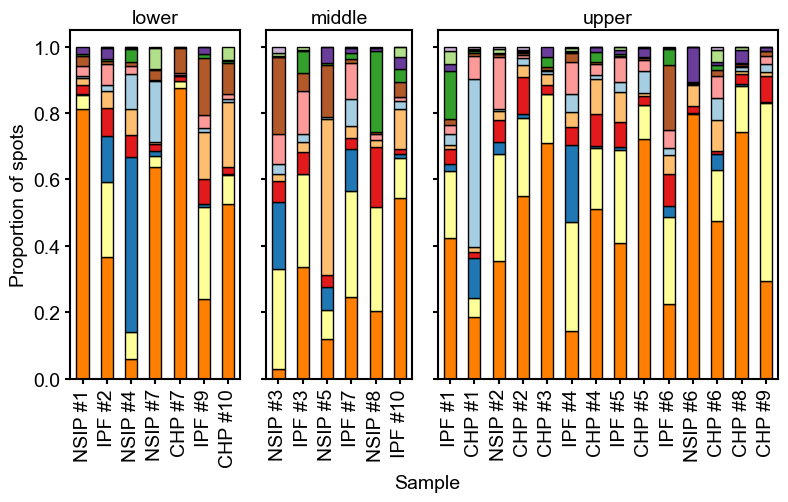

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_70220/3029587987.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_legend.show()


<Figure size 400x200 with 0 Axes>

In [36]:
lobes = ["lower", 'middle', 'upper']


import matplotlib.gridspec as gridspec

# Custom width ratios (adjust as needed — one per condition)
widths = [
    pivot_df[pivot_df['lobe'] == lobes[0]].shape[0] * 0.15,
    pivot_df[pivot_df['lobe'] == lobes[1]].shape[0] * 0.15,
    pivot_df[pivot_df['lobe'] == lobes[2]].shape[0] * 0.15
]

fig = plt.figure(figsize=(sum(widths) * 2, 5))  # overall figure size
gs = gridspec.GridSpec(1, len(lobes), width_ratios=widths)

axes = [fig.add_subplot(gs[i]) for i in range(len(lobes))]



# Step 4: Plot each condition
for ax, lobe in zip(axes, lobes):
    #subset = pivot_df[pivot_df['lobe'] == lobe].drop(columns='lobe').dropna()
    subset = (pivot_df[pivot_df['lobe'] == lobe]
              .drop(columns='lobe')
              .rename(index = key_map) # .rename() updates library_id with lay_id
              .sort_index(
                  key=lambda idx: [int(label.split('#')[1]) for label in idx.astype(str)]
                  )
                .dropna()
                
            ) # sorts it naturally from 1 to 10

    
    
    # do NOT strip everything before #
    #subset.index = "#" + subset.index.astype(str).str.split("#").str[1]

    subset.plot(kind='bar', stacked=True, ax=ax,
                color=color_dict, edgecolor='black')
    ax.set_title(f'{lobe}', fontsize = 14, pad = 5)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Proportion of spots')
    ax.legend().set_title('Factor')

for i in range(3):
    axes[i].get_legend().remove()

for ax in axes:
    ax.set_xlabel("")

for ax in axes[1:]:
    ax.tick_params(labelleft=False)
    ax.set_ylabel("")


fig.text(0.5, 0, "Sample", fontsize = 14)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "stacked_bar_log_minmax_individual_by_lobe.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

# Extract handles and labels
handles, labels = ax.get_legend_handles_labels()

# Create separate figure for legend
fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
fig_legend.legend(handles, labels, title="Niches", loc='center', frameon=False, ncol=4)  # ncol=2 for horizontal spread
fig_legend.tight_layout()
fig_legend.show()


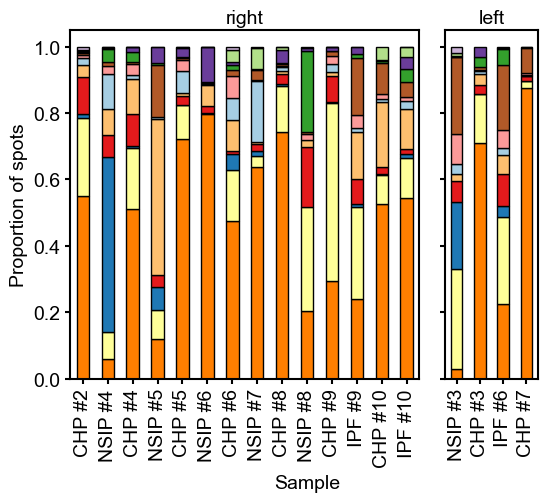

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_70220/2243164796.py:63: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_legend.show()


<Figure size 400x200 with 0 Axes>

In [41]:
lobes_lr = ["right", 'left']

import matplotlib.gridspec as gridspec

# Custom width ratios (adjust as needed — one per condition)
widths = [
    pivot_df[pivot_df['lobe_lr'] == lobes_lr[0]].shape[0] * 0.15,
    pivot_df[pivot_df['lobe_lr'] == lobes_lr[1]].shape[0] * 0.15
]

fig = plt.figure(figsize=(sum(widths) * 2, 5))  # overall figure size
gs = gridspec.GridSpec(1, len(lobes_lr), width_ratios=widths)

axes = [fig.add_subplot(gs[i]) for i in range(len(lobes_lr))]



# Step 4: Plot each condition
for ax, lobe_lr in zip(axes, lobes_lr):
    #subset = pivot_df[pivot_df['lobe_lr'] == lobe_lr].drop(columns='lobe_lr').dropna()
    subset = (pivot_df[pivot_df['lobe_lr'] == lobe_lr]
              .drop(columns='lobe_lr')
              .rename(index = key_map) # .rename() updates library_id with lay_id
              .sort_index(
                  key=lambda idx: [int(label.split('#')[1]) for label in idx.astype(str)])
                .dropna()
                  ) # sorts it naturally from 1 to 10
    
    # do NOT strip everything before #
    #subset.index = "#" + subset.index.astype(str).str.split("#").str[1]
    
    subset.plot(kind='bar', stacked=True, ax=ax,
                color=color_dict, edgecolor='black')
    ax.set_title(f'{lobe_lr}', fontsize = 14, pad = 5)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Proportion of spots')
    ax.legend().set_title('Factor')

for i in range(2):
    axes[i].get_legend().remove()

for ax in axes:
    ax.set_xlabel("")

for ax in axes[1:]:
    ax.tick_params(labelleft=False)
    ax.set_ylabel("")


fig.text(0.5, 0, "Sample", fontsize = 14)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "stacked_bar_log_minmax_individual_by_lr.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

# Extract handles and labels
handles, labels = ax.get_legend_handles_labels()

# Create separate figure for legend
fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
fig_legend.legend(handles, labels, title="Niches", loc='center', frameon=False, ncol=4)  # ncol=2 for horizontal spread
fig_legend.tight_layout()
fig_legend.show()


In [42]:
adata_vis.obs.to_csv(os.path.join(save_dir,"adata_vis_obs.csv"))

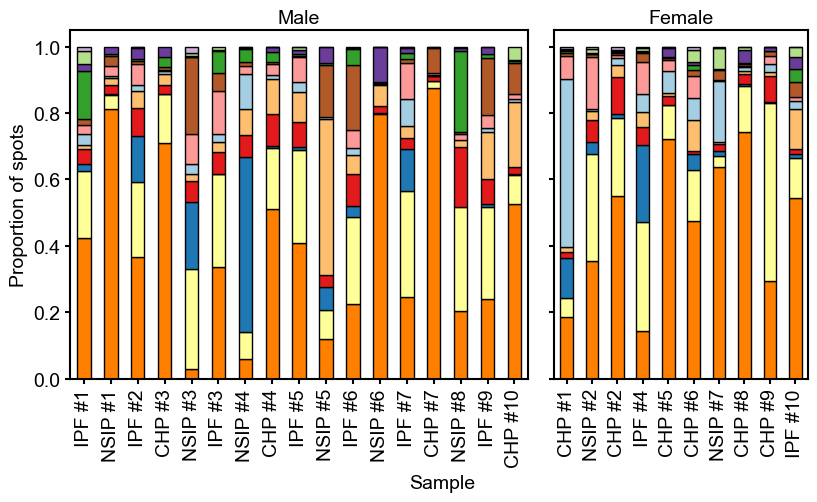

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_70220/2908906562.py:67: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_legend.show()


<Figure size 400x200 with 0 Axes>

In [40]:
sex = ["M", 'F']

import matplotlib.gridspec as gridspec

# Custom width ratios (adjust as needed — one per condition)
widths = [
    pivot_df[pivot_df['sex'] == sex[0]].shape[0] * 0.15,
    pivot_df[pivot_df['sex'] == sex[1]].shape[0] * 0.15
]

fig = plt.figure(figsize=(sum(widths) * 2, 5))  # overall figure size
gs = gridspec.GridSpec(1, len(lobes_lr), width_ratios=widths)

axes = [fig.add_subplot(gs[i]) for i in range(len(lobes_lr))]



# Step 4: Plot each condition
for ax, sex in zip(axes, sex):
    #subset = pivot_df[pivot_df['sex'] == sex].drop(columns='sex').dropna()
    subset = (pivot_df[pivot_df['sex'] == sex]
              .drop(columns='sex')
              .rename(index = key_map) # .rename() updates library_id with lay_id
              .sort_index(
                  key=lambda idx: [int(label.split('#')[1]) for label in idx.astype(str)]
                  )
                .dropna()
                  ) # sorts it naturally from 1 to 10
    
    # do NOT strip everything before #
    #subset.index = "#" + subset.index.astype(str).str.split("#").str[1]

    subset.plot(kind='bar', stacked=True, ax=ax,
                color=color_dict, edgecolor='black')
    if sex == "M":
        ax.set_title('Male', fontsize = 14, pad = 5)
    else:
        ax.set_title('Female', fontsize = 14, pad = 5)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Proportion of spots')
    ax.legend().set_title('Factor')

for i in range(2):
    axes[i].get_legend().remove()

for ax in axes:
    ax.set_xlabel("")

for ax in axes[1:]:
    ax.tick_params(labelleft=False)
    ax.set_ylabel("")


fig.text(0.5, 0, "Sample", fontsize = 14)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "stacked_bar_log_minmax_individual_by_sex.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

# Extract handles and labels
handles, labels = ax.get_legend_handles_labels()

# Create separate figure for legend
fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
fig_legend.legend(handles, labels, title="Niches", loc='center', frameon=False, ncol=4)  # ncol=2 for horizontal spread
fig_legend.tight_layout()
fig_legend.show()


In [44]:
# probe_lot = ["M", 'F']

# import matplotlib.gridspec as gridspec

# # Custom width ratios (adjust as needed — one per condition)
# widths = [
#     pivot_df[pivot_df['probe_lot'] == sex[0]].shape[0] * 0.15,
#     pivot_df[pivot_df['probe_lot'] == sex[1]].shape[0] * 0.15
# ]

# fig = plt.figure(figsize=(sum(widths) * 2, 5))  # overall figure size
# gs = gridspec.GridSpec(1, len(lobes_lr), width_ratios=widths)

# axes = [fig.add_subplot(gs[i]) for i in range(len(lobes_lr))]



# # Step 4: Plot each condition
# for ax, sex in zip(axes, sex):
#     subset = pivot_df[pivot_df['sex'] == sex].drop(columns='sex').dropna()
#     subset.plot(kind='bar', stacked=True, ax=ax,
#                 color=color_dict, edgecolor='black')
#     if sex == "M":
#         ax.set_title('Male', fontsize = 14, pad = 5)
#     else:
#         ax.set_title('Female', fontsize = 14, pad = 5)
#     ax.set_xlabel('Sample')
#     ax.set_ylabel('Proportion of spots')
#     ax.legend().set_title('Factor')

# for i in range(2):
#     axes[i].get_legend().remove()

# for ax in axes:
#     ax.set_xlabel("")

# for ax in axes[1:]:
#     ax.tick_params(labelleft=False)
#     ax.set_ylabel("")


# fig.text(0.5, -0.02, "Sample", fontsize = 14)

# plt.tight_layout()
# plt.savefig(os.path.join(save_dir, "stacked_bar_log_minmax_individual_by_sex.pdf"), bbox_inches = 'tight', transparent = True)
# plt.show()

# # Extract handles and labels
# handles, labels = ax.get_legend_handles_labels()

# # Create separate figure for legend
# fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
# fig_legend.legend(handles, labels, title="Niches", loc='center', frameon=False, ncol=4)  # ncol=2 for horizontal spread
# fig_legend.tight_layout()
# fig_legend.show()


In [45]:
pivot_df.iloc[:,:12].to_csv("c2l_niche_prop_n_12.csv", index=True)

In [52]:
pivot_df

factor_assigned,ATI/Endo,Alv. FB/immune,Plasma,SMC,ATII,Immune,Airway,Adv. FB,Perib. FB,Alv. macro,Macro,B,cond,lobe,lobe_lr,outcome_24m,outcome_long,sex
library_id,,,,,,,,,,,,,,,,,,
06_30914_A1,0.638118,0.031063,0.017085,0.021522,0.005769,0.182161,0.002884,0.029732,0.000000,0.004438,0.063013,0.004216,NSIP,lower,right,ALIVE,ALIVE,F
08_38774_B2,0.292816,0.537864,0.001553,0.078058,0.012816,0.025243,0.023689,0.013592,0.002330,0.010485,0.000388,0.001165,CHP,upper,right,ALIVE,ALIVE,F
11_13888_A1,0.875311,0.021012,0.000829,0.013824,0.000829,0.001659,0.008294,0.074924,0.000000,0.002212,0.001106,0.000000,CHP,lower,left,ALIVE,ALIVE,M
16_39724_B1,0.526996,0.087452,0.000380,0.021293,0.195437,0.011787,0.012548,0.094677,0.005323,0.003422,0.040684,0.000000,CHP,lower,right,ALIVE,ALIVE,M
17_25789_B1,0.743604,0.136364,0.006805,0.031301,0.008165,0.012793,0.003811,0.004627,0.004083,0.037561,0.010615,0.000272,CHP,upper,right,ALIVE,DEAD,F
18_57617_A1,0.422113,0.201843,0.021883,0.046070,0.012669,0.032249,0.026202,0.018140,0.143968,0.021307,0.040311,0.013245,IPF,upper,left,DEAD,DEAD,M
19_18542_A4,0.202880,0.313191,0.000000,0.181023,0.020057,0.000000,0.020057,0.004371,0.246079,0.006943,0.005400,0.000000,NSIP,middle,right,DEAD,DEAD,M
19_35057_C3,0.812804,0.042450,0.001160,0.026444,0.023892,0.005103,0.028764,0.032243,0.005799,0.021341,0.000000,0.000000,NSIP,lower,right,ALIVE,ALIVE,M
20_17688_B2,0.352537,0.324448,0.034394,0.068501,0.025795,0.005732,0.157352,0.008312,0.001146,0.003726,0.009745,0.008312,NSIP,upper,right,ALIVE,LTx,F


In [128]:
niches_of_interest = ["ATII", "Alv. macro","Immune", "Perib. FB",'SMC']
plot_df = (
    pivot_df
    .loc[:, ["cond"] + niches_of_interest]
    .reset_index()          # keep sample ID
    .rename(columns={"index": "sample"})
    .melt(
        id_vars=["library_id", "cond"],
        value_vars=niches_of_interest,
        var_name="niche",
        value_name="value"
    )
)

In [129]:
plot_df

,library_id,cond,niche,value
0,06_30914_A1,NSIP,ATII,0.005769
1,08_38774_B2,CHP,ATII,0.012816
2,11_13888_A1,CHP,ATII,0.000829
3,16_39724_B1,CHP,ATII,0.195437
4,17_25789_B1,CHP,ATII,0.008165
5,18_57617_A1,IPF,ATII,0.012669
6,19_18542_A4,NSIP,ATII,0.020057
7,19_35057_C3,NSIP,ATII,0.023892
8,20_17688_B2,NSIP,ATII,0.025795
9,20_22642_A1,NSIP,ATII,0.018932


/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 32.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


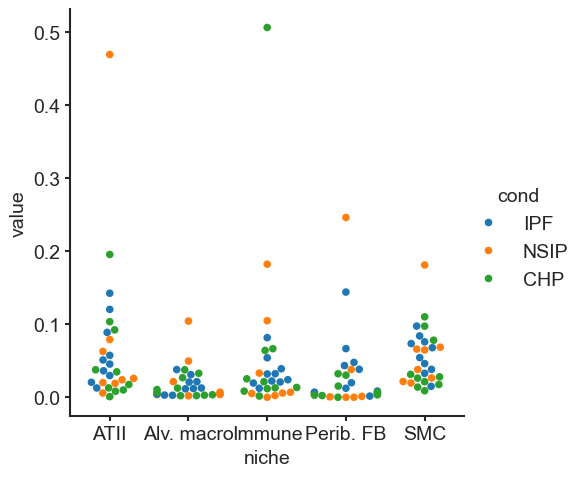

In [130]:
import seaborn as sns
sns.catplot(data = plot_df, x = 'niche', y = 'value', hue = 'cond', kind = 'swarm', s= 30)

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


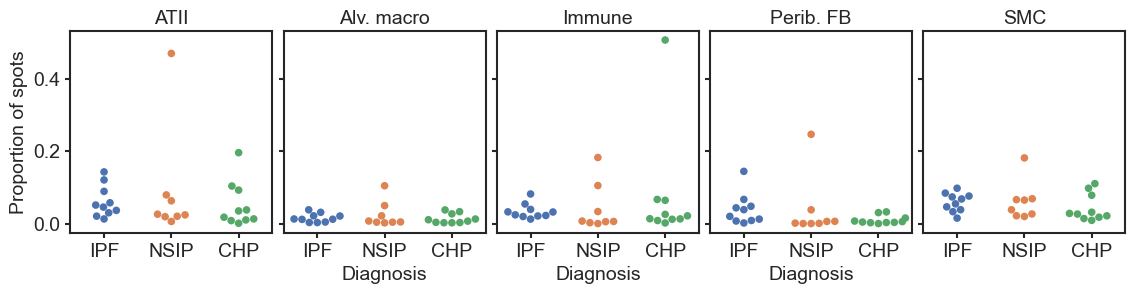

In [132]:
import seaborn as sns
g = sns.catplot(data = plot_df, x = 'cond', y = 'value', col = 'niche', kind = 'swarm', s=30, aspect = 1, hue = 'cond', palette = sns.color_palette("deep", n_colors=3))
g.set(xlabel = "Diagnosis", ylabel = "Proportion of spots")
g.set_titles("{col_name}", pad = 5)

axes = g.axes.flat

axes[0].set(xlabel="")      # first plot
axes[-1].set(xlabel="")     # last plot


for ax in g.axes.flat:
    ax.set_box_aspect(1) 
    sns.despine(right=False, top = False)
    


g.fig.set_size_inches(11, 3)  # width, height in inches
g.fig.savefig(
    os.path.join(save_dir, "swarm_by_condition_and_niche.pdf"),
    bbox_inches="tight",
    transparent=True
)